In [12]:
# 11/2025
###########################################################################################
# using linear model to test correlation
#	Testing correlation
#   Plotting results
#   Diagnostics of the model
#   non-parametric alternative if necessary (not yet implemented)

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [19]:
curRoot = 'C'  # 'C' or 'D'
curProject = 'ataxia'
curDB = 'Atril'

curRegion = 'FCLp-subsc-FCLa-INSULA'

inFileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\{curDB}_combined\{curRegion}.csv'
print(inFileName)
merged_info = pd.read_csv(inFileName)


C:\B_projWIP\proj_ataxia\Champollion\Atril_combined\FCLp-subsc-FCLa-INSULA.csv


In [21]:
##############  verification of NA values  ##############
merged_info.isna().sum()
nan_counts = merged_info.isna().sum().sort_values(ascending=False)
#print(nan_counts)

In [29]:
################################  Data Selection  ################################
left_hem = merged_info[merged_info['Hemisphere'] == 'Left']
right_hem = merged_info[merged_info['Hemisphere'] == 'Right']

############################ !!!!!!!!!!!!!!!  CHANGE  !!!!!!!!!!!!!!  ###########################
# Define the dataset
cur_info = merged_info

In [39]:
################################  LM tests, parametric, shape vs duration_amputation  #################################
##  test correlation between duration_amputation and shape, morphometry and asymmetry  ################################

#diag_measures = ['CAGlong','SARA','INAS']
diag_measures = ['CAGlong']
shape_measures = ['iso1','iso2','iso3']

# Dictionary to store results
model_results = {}

for shape_measure in shape_measures:
    for diag_measure in diag_measures:
        
        #formula = f'{shape_measure} ~ {diag_measure} + Hemisphere + Age + Sex'
        formula = f'{diag_measure} ~ {shape_measure} + Hemisphere + Age + Sex'        
        #formula = f'{shape_measure} ~ {diag_measure} + Age + Sex'   # effect of diagnosis on shape, Test if shape_measure is explained by diagnosis
        #formula = f'{diag_measure} ~ {shape_measure} + Age + Sex'  # effect of shape on diagnosis, test if shape_measure is associated with diagnosis
        
        model = smf.ols(formula, data=cur_info).fit()
        model_results[shape_measure] = model
        print(f'========================= Results for {shape_measure} and {diag_measure} ===========================')
        print(model.summary())
        print('\n')

========================= Results for iso1 and CAGlong ===========================
                            OLS Regression Results                            
Dep. Variable:                CAGlong   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     27.85
Date:                Fri, 14 Nov 2025   Prob (F-statistic):           8.51e-10
Time:                        16:21:02   Log-Likelihood:                -74.305
No. Observations:                  43   AIC:                             156.6
Df Residuals:                      39   BIC:                             163.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

In [ ]:
diag_measures = ['CAGlong']
shape_measures = ['iso1','iso2','iso3']

# Dictionary to store results
model_results = {}

for shape_measure in shape_measures:
    for diag_measure in diag_measures:
        
        formula = f'{diag_measure} ~ {shape_measure} + Age + Sex'  # effect of shape on diagnosis, test if shape_measure is associated with diagnosis
        
        model = smf.ols(formula, data=cur_info).fit()
        model_results[shape_measure] = model
        print(f'========================= Results for {shape_measure} and {diag_measure} ===========================')
        print(model.summary())
        print('\n')

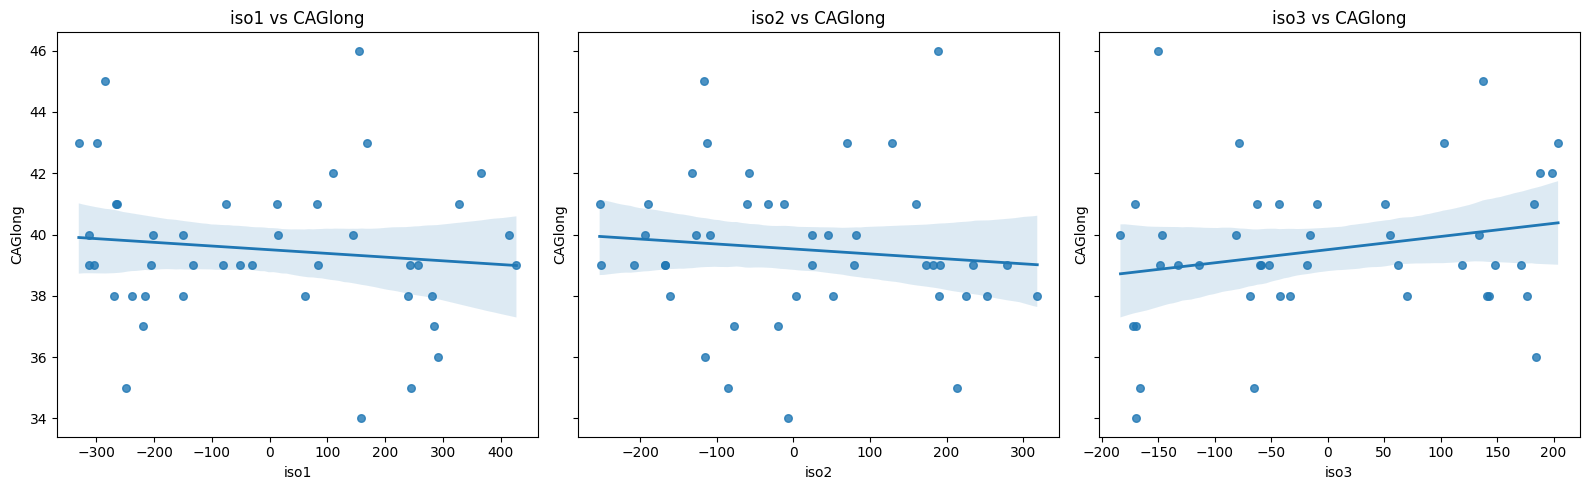

In [41]:
#####################  correlation plots  ###################

diag_measure = 'CAGlong'
shape_measures = ['iso1', 'iso2', 'iso3']

fig, axes = plt.subplots(1, len(shape_measures), figsize=(16, 5), sharey=True)

for ax, shape_measure in zip(axes, shape_measures):
    
    # Scatter with regression line
    sns.regplot(
        data=cur_info,
        x=shape_measure,
        y=diag_measure,
        ax=ax,
        scatter_kws={'s': 30},       # point size
        line_kws={'linewidth': 2}    # line thickness
    )
    
    ax.set_title(f'{shape_measure} vs {diag_measure}', fontsize=12)
    ax.set_xlabel(shape_measure)
    ax.set_ylabel(diag_measure)

plt.tight_layout()
plt.show()


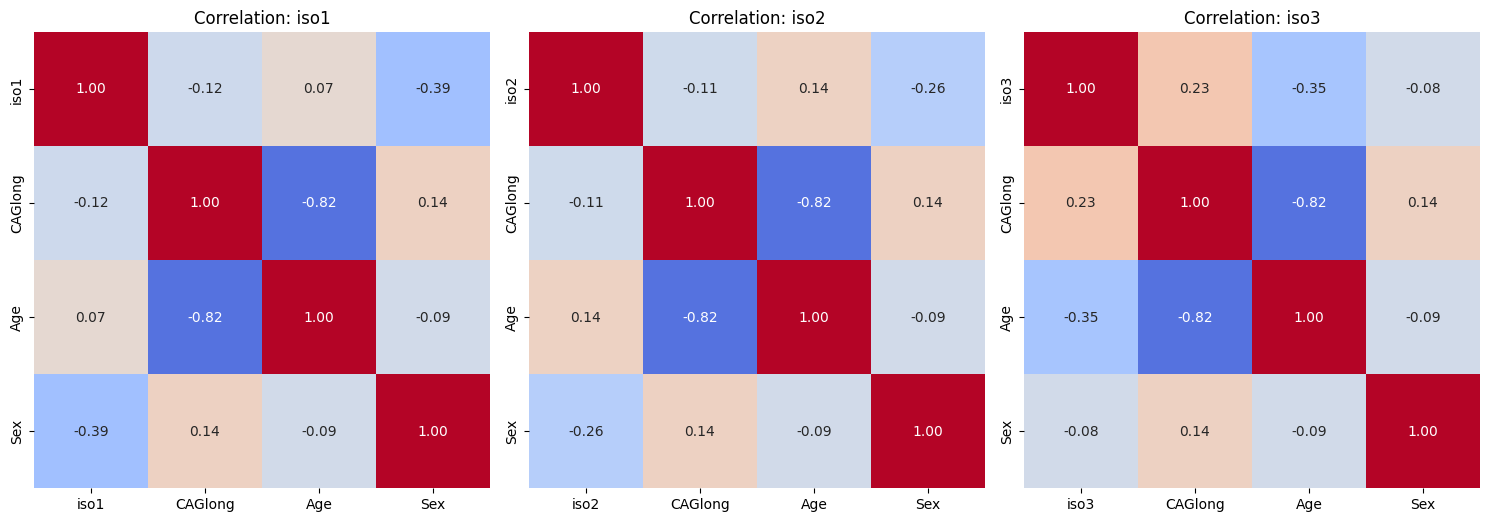

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

diag_measure = 'CAGlong'
shape_measures = ['iso1', 'iso2', 'iso3']

fig, axes = plt.subplots(1, len(shape_measures), figsize=(15, 5))

for ax, shape_measure in zip(axes, shape_measures):
    
    # Select relevant columns
    cols = [shape_measure, diag_measure, 'Age', 'Sex']
    corr = cur_info[cols].corr()
    
    # Plot heatmap
    sns.heatmap(
        corr, annot=True, cmap='coolwarm', center=0,
        ax=ax, fmt=".2f", square=True, cbar=False
    )
    
    ax.set_title(f'Correlation: {shape_measure}')

plt.tight_layout()
plt.show()
